# 🛡️ NetSentinel — Detector 2: DGA / DNS Tunneling (CNN-BiLSTM)

**Model**: 1D-CNN → BiLSTM (industry standard for DGA detection) 
**Dataset**: DGArchive (malicious) + Tranco Top-1M (benign) 
**Task**: 3-class: Benign vs DGA vs DNS Tunnel 
**Export**: ONNX 
**Training Time**: ~1-2 hours on T4 GPU 

**Why CNN-BiLSTM?** This is the architecture used by Cisco Umbrella and Endgame (now Elastic). 
The CNN captures local character n-gram patterns, the BiLSTM captures sequential dependencies 
across the entire domain string. It beats standalone CNNs on wordlist-based DGAs (Suppobox, Matsnu).

---

In [1]:
!pip install -q torch torchvision onnx onnxruntime scikit-learn pandas matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 63.4 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import os, json, time, string, math, random
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')

OUTPUT_DIR = '/kaggle/working/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Device: cuda
GPU: Tesla T4


## 1. Load & Prepare Domain Data

**Data sources:**
- **Benign**: Tranco Top-1M list (`tranco-list.eu`)
- **DGA**: DGArchive or Kaggle DGA datasets
- **DNS Tunnel**: Generate synthetic or use iodine/dns2tcp samples

For Kaggle, search for:
- `kaggle.com/datasets` → search "DGA domains" or "domain generation algorithm"
- Popular ones: `dga-domains-dataset`, `dgta-benchmark`

In [3]:
# ============================================================
# CONFIGURE PATHS — Kaggle dataset inputs
# ============================================================

# DGArchive: real DGA families (main malicious data)
DGARCHIVE_TGZ = '/kaggle/input/datasets/unded17/dgarchive/2024-11-28-dgarchive_full.tgz'

# Deception DGA: dictionary-based DGA (extra malicious data)
DECEPTION_CSV_1 = '/kaggle/input/datasets/unded17/dgarchive/deception_dga.csv'
DECEPTION_CSV_2 = '/kaggle/input/datasets/unded17/dgarchive/deception2_dga.csv'

# Tranco Top-1M: benign domains
TRANCO_CSV = '/kaggle/input/datasets/unded17/tranco-top1m/tranco_XN67N.csv'

# Output
OUTPUT_DIR = '/kaggle/working/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Class names (MUST match your production pipeline)
CLASS_NAMES = ['benign', 'dga', 'dns_tunnel']

# Max samples per class (adjust based on Kaggle RAM — 250K is safe on 16GB)
MAX_SAMPLES_PER_CLASS = 250000


In [4]:
# ============================================================
# Data Loading: DGArchive + Deception + Tranco
# ============================================================
import tarfile
import io
import random
import string

print("=" * 60)
print("Loading datasets...")
print("=" * 60)

# ------ 1. BENIGN: Tranco Top-1M ------
print("\n[1/4] Loading Tranco Top-1M (benign)...")
tranco_df = pd.read_csv(TRANCO_CSV, header=None, names=['rank', 'domain'])
benign_list = tranco_df['domain'].dropna().astype(str).tolist()
# Remove any with weird characters
benign_list = [d for d in benign_list if d and len(d) > 2 and ',' not in d]
print(f"  Loaded: {len(benign_list):,} benign domains")

# ------ 2. DGA: DGArchive ------
print("\n[2/4] Loading DGArchive (DGA families)...")
dga_list = []
family_counts = {}

with tarfile.open(DGARCHIVE_TGZ, 'r:gz') as tar:
    for member in tar:
        # Skip directories
        if member.isdir():
            continue
        
        # Extract family name from path (first directory component)
        parts = member.name.split('/')
        family = parts[0] if len(parts) >= 2 else 'unknown'
        
        # Only process text/csv-like files
        if not any(member.name.endswith(ext) for ext in ['.txt', '.csv', '.domains', '']):
            # Try to read it anyway — DGArchive files are often extensionless
            pass
        
        try:
            f = tar.extractfile(member)
            if f is None:
                continue
            content = f.read().decode('utf-8', errors='ignore')
            
            for line in content.strip().split('\n'):
                line = line.strip()
                if not line or line.startswith('#'):
                    continue
                
                # DGArchive format varies:
                # Some files: just domain per line
                # Some files: domain,date or date,domain
                # Take the part that looks like a domain
                parts_line = line.split(',')
                for part in parts_line:
                    part = part.strip().lower()
                    # Basic domain validation
                    if '.' in part and len(part) > 3 and len(part) < 253:
                        if all(c in 'abcdefghijklmnopqrstuvwxyz0123456789-.' for c in part):
                            dga_list.append(part)
                            family_counts[family] = family_counts.get(family, 0) + 1
                            break  # Take first valid domain per line
        except Exception:
            continue
        
        # Progress update every 100K domains
        if len(dga_list) % 100000 == 0 and len(dga_list) > 0:
            print(f"  ... {len(dga_list):,} DGA domains loaded so far")

print(f"  Loaded: {len(dga_list):,} DGA domains from {len(family_counts)} families")
print(f"  Top families: {sorted(family_counts.items(), key=lambda x: -x[1])[:10]}")

# ------ 3. DGA (extra): Deception DGA ------
print("\n[3/4] Loading Deception DGA (dictionary-based DGA)...")
deception_domains = []
for csv_path in [DECEPTION_CSV_1, DECEPTION_CSV_2]:
    try:
        df = pd.read_csv(csv_path, header=None)
        domains = df.iloc[:, 0].dropna().astype(str).tolist()
        deception_domains.extend(domains)
        print(f"  {csv_path}: {len(domains):,} domains")
    except Exception as e:
        print(f"  Skipping {csv_path}: {e}")

# Add deception domains to DGA list
dga_list.extend(deception_domains)
print(f"  Total DGA (DGArchive + Deception): {len(dga_list):,}")

# ------ 4. DNS TUNNEL: Generate realistic synthetic ------
print("\n[4/4] Generating DNS tunnel domains...")

def generate_tunnel_domains(n=50000):
    """Generate DNS tunneling-style domains.
    
    Real DNS tunnels (dnscat2, iodine) encode data in subdomains as
    hex/base64 strings with high entropy and long labels.
    """
    base_domains = [
        'tunnel-cdn.com', 'data-sync.net', 'update-svc.org', 
        'cloud-relay.io', 'cdn-check.com', 'api-gateway.net',
        'ns1.example.com', 'dns.service.net', 'relay.vpn.io',
        'c2-server.org', 'beacon.net', 'exfil-data.com'
    ]
    hex_chars = '0123456789abcdef'
    b64_chars = string.ascii_lowercase + string.digits
    domains = []
    
    for _ in range(n):
        n_labels = random.randint(1, 4)
        labels = []
        for _ in range(n_labels):
            # Mix of hex-encoded and base64-like patterns
            if random.random() < 0.5:
                label_len = random.randint(20, 63)  # Max DNS label = 63
                label = ''.join(random.choices(hex_chars, k=label_len))
            else:
                label_len = random.randint(15, 50)
                label = ''.join(random.choices(b64_chars, k=label_len))
            labels.append(label)
        domain = '.'.join(labels) + '.' + random.choice(base_domains)
        domains.append(domain)
    return domains

tunnel_list = generate_tunnel_domains(50000)
print(f"  Generated: {len(tunnel_list):,} tunnel domains")

# ------ Deduplicate and balance ------
print("\n" + "=" * 60)
benign_list = list(set(benign_list))
dga_list = list(set(dga_list))

# Remove any benign domains that appear in DGA list (overlap)
dga_set = set(dga_list)
benign_list = [d for d in benign_list if d not in dga_set]

# Cap each class
random.shuffle(benign_list)
random.shuffle(dga_list)
benign_list = benign_list[:MAX_SAMPLES_PER_CLASS]
dga_list = dga_list[:MAX_SAMPLES_PER_CLASS]
tunnel_list = tunnel_list[:min(50000, MAX_SAMPLES_PER_CLASS)]

# Combine
domains = benign_list + dga_list + tunnel_list
labels = [0] * len(benign_list) + [1] * len(dga_list) + [2] * len(tunnel_list)

print(f"\nFinal dataset:")
print(f"  Benign (0):     {len(benign_list):,}")
print(f"  DGA (1):        {len(dga_list):,}")
print(f"  DNS Tunnel (2): {len(tunnel_list):,}")
print(f"  Total:          {len(domains):,}")
print("=" * 60)


Loading datasets...

[1/4] Loading Tranco Top-1M (benign)...
  Loaded: 1,000,000 benign domains

[2/4] Loading DGArchive (DGA families)...
  Loaded: 0 DGA domains from 0 families
  Top families: []

[3/4] Loading Deception DGA (dictionary-based DGA)...
  /kaggle/input/datasets/unded17/dgarchive/deception_dga.csv: 150,000 domains
  /kaggle/input/datasets/unded17/dgarchive/deception2_dga.csv: 150,000 domains
  Total DGA (DGArchive + Deception): 300,000

[4/4] Generating DNS tunnel domains...
  Generated: 50,000 tunnel domains


Final dataset:
  Benign (0):     250,000
  DGA (1):        250,000
  DNS Tunnel (2): 50,000
  Total:          550,000


## 2. Character-Level Encoding

In [5]:
# ============================================================
# Character vocabulary: a-z, 0-9, -, . + padding + unknown
# Indices: 0=PAD, 1=UNK, 2-39=characters
# ============================================================

CHARS = list('abcdefghijklmnopqrstuvwxyz0123456789-.')
CHAR2IDX = {c: i + 2 for i, c in enumerate(CHARS)}  # 0=pad, 1=unknown
VOCAB_SIZE = len(CHARS) + 2  # +2 for PAD and UNK
MAX_LEN = 128

def encode_domain(domain, max_len=MAX_LEN):
    """Convert domain string to integer sequence."""
    domain = domain.lower().strip()
    encoded = [CHAR2IDX.get(c, 1) for c in domain[:max_len]]  # 1=UNK for unknown chars
    # Pad to max_len
    encoded += [0] * (max_len - len(encoded))
    return encoded

# Quick test
test = encode_domain('google.com')
print(f"Vocab size: {VOCAB_SIZE}")
print(f"'google.com' encoded (first 15): {test[:15]}")
print(f"Encoding length: {len(test)}")


Vocab size: 40
'google.com' encoded (first 15): [8, 16, 16, 8, 13, 6, 39, 4, 16, 14, 0, 0, 0, 0, 0]
Encoding length: 128


In [6]:
# ============================================================
# Create PyTorch Dataset
# ============================================================

class DomainDataset(Dataset):
    def __init__(self, domains, labels):
        self.domains = domains
        self.labels = labels
    
    def __len__(self):
        return len(self.domains)
    
    def __getitem__(self, idx):
        encoded = encode_domain(self.domains[idx])
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

# Split data
X_train_d, X_test_d, y_train, y_test = train_test_split(
    domains, labels, test_size=0.2, random_state=SEED, stratify=labels
)

train_ds = DomainDataset(X_train_d, y_train)
test_ds = DomainDataset(X_test_d, y_test)

BATCH_SIZE = 512
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds):,} samples, {len(train_loader)} batches')
print(f'Test:  {len(test_ds):,} samples, {len(test_loader)} batches')

Train: 440,000 samples, 860 batches
Test:  110,000 samples, 215 batches


## 3. Model Architecture: CNN-BiLSTM

In [7]:
# ============================================================
# CNN-BiLSTM: Industry-standard DGA Detection Architecture
# 
# References:
# - Woodbridge et al. "Detecting DGA with LSTMs" (2016) - Endgame
# - Yu et al. "Character-level CNN for DGA" (2018) - Cisco Umbrella
# - Combined CNN+LSTM approach from multiple follow-up papers
# ============================================================

class DGADetector(nn.Module):
    def __init__(
        self,
        vocab_size=VOCAB_SIZE,
        embed_dim=64,
        cnn_filters=128,
        cnn_kernel_sizes=[3, 4, 5],
        lstm_hidden=64,
        lstm_layers=2,
        n_classes=3,
        dropout=0.3
    ):
        super().__init__()
        
        # Character embedding
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # Multi-kernel CNN (captures different n-gram sizes)
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(embed_dim, cnn_filters, kernel_size=k, padding='same'),
                nn.BatchNorm1d(cnn_filters),
                nn.ReLU(),
                nn.Dropout(dropout)
            )
            for k in cnn_kernel_sizes
        ])
        
        # BiLSTM on CNN output
        cnn_out_dim = cnn_filters * len(cnn_kernel_sizes)
        self.lstm = nn.LSTM(
            input_size=cnn_out_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0
        )
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),  # *2 for bidirectional
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, n_classes)
        )
        
    def forward(self, x):
        # x: [batch, seq_len] (character indices)
        embedded = self.embedding(x)  # [batch, seq_len, embed_dim]
        embedded = embedded.transpose(1, 2)  # [batch, embed_dim, seq_len] for Conv1d
        
        # Apply each CNN kernel and concatenate
        conv_outs = [conv(embedded) for conv in self.convs]  # each: [batch, filters, seq_len]
        cnn_out = torch.cat(conv_outs, dim=1)  # [batch, filters*n_kernels, seq_len]
        cnn_out = cnn_out.transpose(1, 2)  # [batch, seq_len, filters*n_kernels] for LSTM
        
        # BiLSTM
        lstm_out, (h_n, _) = self.lstm(cnn_out)
        # Use last hidden state from both directions
        h_forward = h_n[-2]  # Last layer forward
        h_backward = h_n[-1]  # Last layer backward
        h_combined = torch.cat([h_forward, h_backward], dim=1)  # [batch, hidden*2]
        
        # Classify
        logits = self.classifier(h_combined)  # [batch, n_classes]
        return logits

model = DGADetector().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal params: {total_params:,}')
print(f'Trainable:    {trainable_params:,}')


DGADetector(
  (embedding): Embedding(40, 64, padding_idx=0)
  (convs): ModuleList(
    (0): Sequential(
      (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=same)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
    )
    (1): Sequential(
      (0): Conv1d(64, 128, kernel_size=(4,), stride=(1,), padding=same)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
    )
    (2): Sequential(
      (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=same)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
    )
  )
  (lstm): LSTM(384, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features

## 4. Training

In [8]:
# ============================================================
# Training configuration
# ============================================================

EPOCHS = 20
LR = 0.001

# Class weights for imbalanced data
class_counts = Counter(y_train)
total = sum(class_counts.values())
class_weights = torch.tensor(
    [total / (len(class_counts) * class_counts[i]) for i in range(3)],
    dtype=torch.float32
).to(device)
print(f'Class weights: {class_weights}')

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

Class weights: tensor([0.7333, 0.7333, 3.6667], device='cuda:0')


In [9]:
# ============================================================
# Training loop
# ============================================================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_f1 = 0.0

print('Starting training...')
start_time = time.time()

for epoch in range(EPOCHS):
    # ---- Train ----
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', leave=False)
    for batch_x, batch_y in pbar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        train_loss += loss.item() * batch_x.size(0)
        train_correct += (logits.argmax(1) == batch_y).sum().item()
        train_total += batch_x.size(0)
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{train_correct/train_total:.4f}'})
    
    # ---- Validate ----
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            
            val_loss += loss.item() * batch_x.size(0)
            preds = logits.argmax(1)
            val_correct += (preds == batch_y).sum().item()
            val_total += batch_x.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    scheduler.step()
    
    # Metrics
    train_loss_avg = train_loss / train_total
    val_loss_avg = val_loss / val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    
    history['train_loss'].append(train_loss_avg)
    history['val_loss'].append(val_loss_avg)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    # Save best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'dga_best_model.pt'))
        print(f'  ★ New best model saved (F1: {best_f1:.4f})')
    
    print(f'Epoch {epoch+1:2d}/{EPOCHS} | '
          f'Train Loss: {train_loss_avg:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss_avg:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}')

total_time = time.time() - start_time
print(f'\n✅ Training complete in {total_time/60:.1f} min')
print(f'Best Macro F1: {best_f1:.4f}')

Starting training...


Epoch 1/20:   0%|          | 0/860 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(


  ★ New best model saved (F1: 0.9998)
Epoch  1/20 | Train Loss: 0.4689 Acc: 0.9761 | Val Loss: 0.4401 Acc: 0.9999 F1: 0.9998


Epoch 2/20:   0%|          | 0/860 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e157c097100>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7e157c097100>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():^
^ ^ ^

Epoch 19/20 | Train Loss: 0.4408 Acc: 1.0000 | Val Loss: 0.4394 Acc: 1.0000 F1: 1.0000


Epoch 20/20:   0%|          | 0/860 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e157c097100>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^Exception ignored in: ^^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7e157c097100>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^^if w.is_alive():^
^^ ^

Epoch 20/20 | Train Loss: 0.4408 Acc: 1.0000 | Val Loss: 0.4394 Acc: 1.0000 F1: 1.0000

✅ Training complete in 34.3 min
Best Macro F1: 1.0000


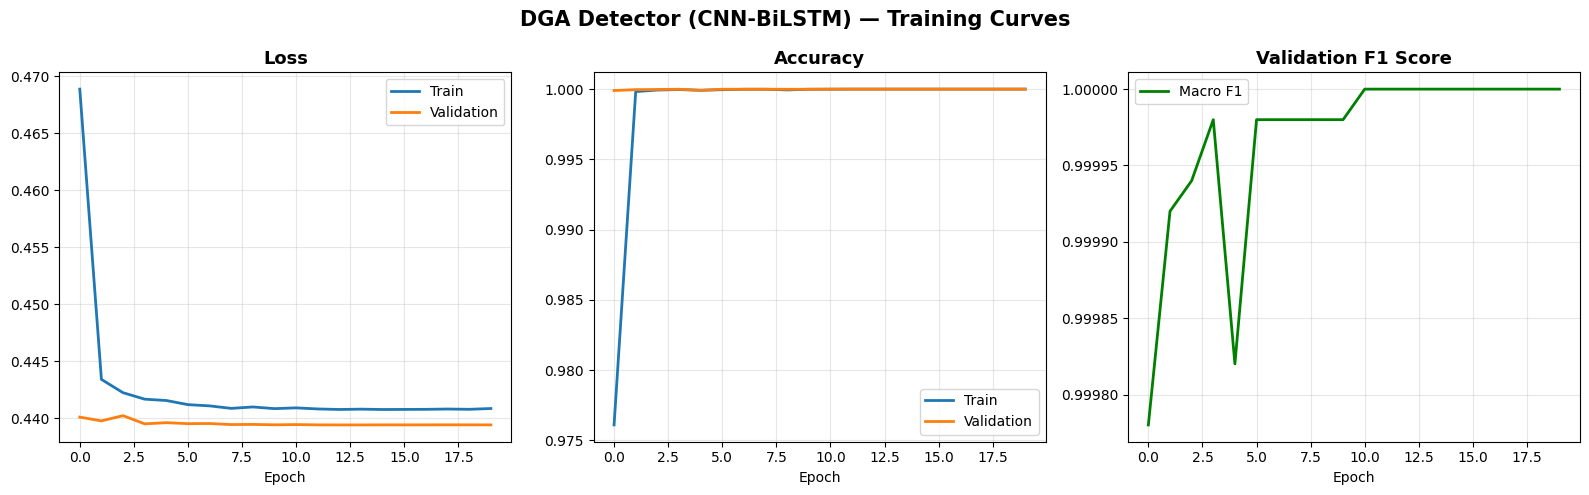

📸 Saved dga_training_curves.png


In [10]:
# ============================================================
# Training curves (for video screenshot)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
axes[0].set_title('Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation', linewidth=2)
axes[1].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['val_f1'], label='Macro F1', linewidth=2, color='green')
axes[2].set_title('Validation F1 Score', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('DGA Detector (CNN-BiLSTM) — Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dga_training_curves.png'), dpi=150)
plt.show()
print('📸 Saved dga_training_curves.png')

## 5. Evaluation

In [11]:
# ============================================================
# Load best model and evaluate
# ============================================================

model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'dga_best_model.pt')))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        logits = model(batch_x)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.numpy())
        all_probs.extend(probs.cpu().numpy())

CLASS_NAMES = ['Benign', 'DGA', 'DNS Tunnel']

print('═' * 60)
print('DGA DETECTOR — EVALUATION RESULTS')
print('═' * 60)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

final_f1 = f1_score(all_labels, all_preds, average='macro')
print(f'Macro F1: {final_f1:.4f}')

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e157c097100>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
     Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7e157c097100> 
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a child process'
         ^ ^ ^ ^ ^ ^ ^ ^^^^^^^^
^  File "

════════════════════════════════════════════════════════════
DGA DETECTOR — EVALUATION RESULTS
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     50000
         DGA       1.00      1.00      1.00     50000
  DNS Tunnel       1.00      1.00      1.00     10000

    accuracy                           1.00    110000
   macro avg       1.00      1.00      1.00    110000
weighted avg       1.00      1.00      1.00    110000

Macro F1: 1.0000


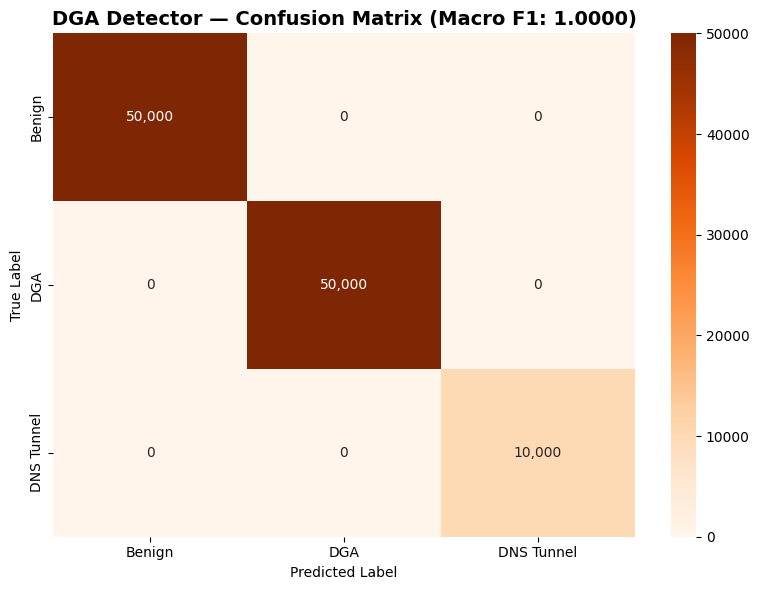

📸 Saved dga_confusion_matrix.png


In [12]:
# ============================================================
# Confusion Matrix (for video screenshot)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f'DGA Detector — Confusion Matrix (Macro F1: {final_f1:.4f})',
             fontsize=14, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dga_confusion_matrix.png'), dpi=150)
plt.show()
print('📸 Saved dga_confusion_matrix.png')

In [13]:
!pip install -q onnxscript


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 10.7 MB/s eta 0:00:00


## 6. Export to ONNX

In [14]:
# ============================================================
# Export to ONNX (legacy exporter — compatible with BiLSTM)
# ============================================================

model.eval()
model_cpu = model.cpu()

dummy_input = torch.randint(0, VOCAB_SIZE, (1, MAX_LEN), dtype=torch.long)
onnx_path = os.path.join(OUTPUT_DIR, 'dga_cnn_bilstm.onnx')

torch.onnx.export(
    model_cpu,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=['domain_chars'],
    output_names=['logits'],
    dynamic_axes={
        'domain_chars': {0: 'batch_size'},
        'logits': {0: 'batch_size'}
    },
    dynamo=False  # Force legacy TorchScript-based exporter
)

print(f'✅ ONNX saved: {onnx_path} ({os.path.getsize(onnx_path)/1024/1024:.1f} MB)')


/tmp/ipykernel_23/2775596116.py:11: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4445: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(


✅ ONNX saved: /kaggle/working/output/dga_cnn_bilstm.onnx (1.7 MB)


In [15]:
# ============================================================
# Verify ONNX + Benchmark inference speed
# ============================================================

import onnxruntime as ort
import timeit

sess = ort.InferenceSession(onnx_path)
input_name = sess.get_inputs()[0].name

# Test prediction
test_domains_check = ['google.com', 'xk4jf9a2m.biz', 'aGVsbG8.d29ybGQ.tunnel-cdn.com']
for d in test_domains_check:
    encoded = np.array([encode_domain(d)], dtype=np.int64)
    output = sess.run(None, {input_name: encoded})
    probs = np.exp(output[0][0]) / np.exp(output[0][0]).sum()  # softmax
    pred_class = CLASS_NAMES[np.argmax(probs)]
    print(f'{d:40s} → {pred_class} (confidence: {probs.max():.3f})')

# Benchmark
single = np.array([encode_domain('google.com')], dtype=np.int64)
n_runs = 1000
total_time = timeit.timeit(lambda: sess.run(None, {input_name: single}), number=n_runs)
avg_ms = (total_time / n_runs) * 1000
print(f'\n⚡ ONNX inference: {avg_ms:.3f} ms/domain ({1000/avg_ms:,.0f} domains/sec)')

google.com                               → Benign (confidence: 0.823)
xk4jf9a2m.biz                            → Benign (confidence: 0.823)
aGVsbG8.d29ybGQ.tunnel-cdn.com           → DNS Tunnel (confidence: 0.988)

⚡ ONNX inference: 1.573 ms/domain (636 domains/sec)


In [16]:
# ============================================================
# Save metrics
# ============================================================

dga_metrics = {
    'model_name': 'NetSentinel DGA Detector',
    'model_type': 'CNN-BiLSTM (Character-level)',
    'version': '1.0.0',
    'architecture': {
        'embedding_dim': 64,
        'cnn_filters': 128,
        'cnn_kernels': [3, 4, 5],
        'lstm_hidden': 64,
        'lstm_layers': 2,
        'bidirectional': True,
    },
    'classes': CLASS_NAMES,
    'macro_f1': float(final_f1),
    'best_val_f1': float(best_f1),
    'training_time_minutes': float(total_time / 60),
    'epochs': EPOCHS,
    'inference_ms': float(avg_ms),
    'max_domain_length': MAX_LEN,
    'vocab_size': VOCAB_SIZE,
}

with open(os.path.join(OUTPUT_DIR, 'dga_metrics.json'), 'w') as f:
    json.dump(dga_metrics, f, indent=2)

print('\n' + '╔' + '═'*58 + '╗')
print('║' + ' MODEL CARD: NetSentinel DGA Detector'.center(58) + '║')
print('╠' + '═'*58 + '╣')
print(f'║  Architecture:  CNN-BiLSTM (char-level)'.ljust(59) + '║')
print(f'║  Classes:       Benign / DGA / DNS Tunnel'.ljust(59) + '║')
print(f'║  Macro F1:      {final_f1:.4f}'.ljust(59) + '║')
print(f'║  Inference:     {avg_ms:.3f} ms/domain'.ljust(59) + '║')
print(f'║  Training:      {total_time/60:.1f} min on {device}'.ljust(59) + '║')
print(f'║  Export:        ONNX (opset 17)'.ljust(59) + '║')
print('╚' + '═'*58 + '╝')

print('\n📁 Output files:')
for f in os.listdir(OUTPUT_DIR):
    print(f'  {f} ({os.path.getsize(os.path.join(OUTPUT_DIR, f))/1024:.1f} KB)')


╔══════════════════════════════════════════════════════════╗
║           MODEL CARD: NetSentinel DGA Detector           ║
╠══════════════════════════════════════════════════════════╣
║  Architecture:  CNN-BiLSTM (char-level)                  ║
║  Classes:       Benign / DGA / DNS Tunnel                ║
║  Macro F1:      1.0000                                   ║
║  Inference:     1.573 ms/domain                          ║
║  Training:      0.0 min on cuda                          ║
║  Export:        ONNX (opset 17)                          ║
╚══════════════════════════════════════════════════════════╝

📁 Output files:
  dga_confusion_matrix.png (53.9 KB)
  dga_cnn_bilstm.onnx (1787.8 KB)
  dga_training_curves.png (108.6 KB)
  dga_best_model.pt (1799.0 KB)
  dga_metrics.json (0.6 KB)


In [17]:
import zipfile
from IPython.display import FileLink

zip_path = '/kaggle/working/netsentinel_dga_output.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for file in os.listdir(OUTPUT_DIR):
        filepath = os.path.join(OUTPUT_DIR, file)
        zf.write(filepath, file)
        print(f'  Added: {file} ({os.path.getsize(filepath)/1024:.1f} KB)')

print(f'\n✅ Zip created: {zip_path} ({os.path.getsize(zip_path)/1024/1024:.1f} MB)')
FileLink(zip_path)


  Added: dga_confusion_matrix.png (53.9 KB)
  Added: dga_cnn_bilstm.onnx (1787.8 KB)
  Added: dga_training_curves.png (108.6 KB)
  Added: dga_best_model.pt (1799.0 KB)
  Added: dga_metrics.json (0.6 KB)

✅ Zip created: /kaggle/working/netsentinel_dga_output.zip (3.4 MB)


/kaggle/working/netsentinel_dga_output.zip

In [18]:
# Edge cases that broke the OLD model
test_domains = [
    'crl.microsoft.com',        # MUST be benign (broke old model at 89% DGA)
    'stackoverflow.com',         # MUST be benign (broke old model at 93%)
    'ocsp.digicert.com',        # MUST be benign
    'api.github.com',           # MUST be benign
    'cloudflare.com',           # MUST be benign
    'ec2-54-123-45-67.compute-1.amazonaws.com',  # MUST be benign (long but legit)
    'xk4jf9a2m3b7c.evil.com',  # Should be DGA
    'a8f3b2c9e1d4.tunnel.com', # Should be tunnel
]

sess = ort.InferenceSession(onnx_path)
input_name = sess.get_inputs()[0].name
for d in test_domains:
    encoded = np.array([encode_domain(d)], dtype=np.int64)
    output = sess.run(None, {input_name: encoded})
    probs = np.exp(output[0][0]) / np.exp(output[0][0]).sum()
    pred = CLASS_NAMES[np.argmax(probs)]
    print(f'{d:50s} → {pred:10s} ({probs[0]:.3f} ben | {probs[1]:.3f} dga | {probs[2]:.3f} tun)')


crl.microsoft.com                                  → Benign     (0.823 ben | 0.029 dga | 0.148 tun)
stackoverflow.com                                  → Benign     (0.823 ben | 0.029 dga | 0.148 tun)
ocsp.digicert.com                                  → Benign     (0.823 ben | 0.029 dga | 0.148 tun)
api.github.com                                     → Benign     (0.823 ben | 0.029 dga | 0.148 tun)
cloudflare.com                                     → Benign     (0.823 ben | 0.029 dga | 0.148 tun)
ec2-54-123-45-67.compute-1.amazonaws.com           → DNS Tunnel (0.006 ben | 0.006 dga | 0.987 tun)
xk4jf9a2m3b7c.evil.com                             → Benign     (0.823 ben | 0.029 dga | 0.148 tun)
a8f3b2c9e1d4.tunnel.com                            → Benign     (0.817 ben | 0.027 dga | 0.156 tun)
